In [1]:
import numpy as np
np.random.seed(123)
import matplotlib.pyplot as plt
import astropy.units as u
%matplotlib widget
from threeML import XYLike, DataList, Model, PointSource, BayesianAnalysis,\
      Uniform_prior, ZDust, TbAbs, clone_model, Log_uniform_prior, load_analysis_results
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
from bhjet.threeML_plugins.BHJetPlugin import BHJetPlugin
from bhjet.threeML_plugins.TargetBlackBody import TargetBlackBody
from bhjet.threeML_plugins.BandLimitedAbsorption import make_band_limited

16:44:06 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=872076;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=382001;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=786568;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=715494;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

16:44:07 INFO      Starting 3ML!                                                                     ]8;id=700076;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=759368;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=411740;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=370556;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/__init__.py#45\45]8;;\

         WARNING   but are inform you about optional packages that can be installed                  ]8;id=716876;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=891024;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/__init__.py#46\46]8;;\

...

         WARNING   Multinest minimizer not available                                           ]8;id=346291;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/minimizer/minimization.py\minimization.py]8;;\:]8;id=4030;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/minimizer/minimization.py#1218\1218]8;;\

         WARNING   PyGMO is not available                                                      ]8;id=100158;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/minimizer/minimization.py\minimization.py]8;;\:]8;id=862845;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/minimizer/minimization.py#1228\1228]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=584442;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=203595;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=994147;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=955335;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=294422;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=158981;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

make bhjet models

In [2]:
bhjet3ml = BHJetPlugin()
bhjet3ml._setup(
    Emin_eV=1e-6, Emax_eV=1e15, 
    dlgz=0.3, verbosity_level=0, 
    compton_threshold=1e-10,
    include_counterjet=True, cache_rtol=1e-4)

bbt1 = TargetBlackBody()

bhjet3ml.add_target(bbt1, "bb1")


* description: Blackbody target container for BHJet
  * formula: $n.a.$
  * parameters:
    * lg_temperature:
      * value: -3.5
      * desc: temperature (log10 keV)
      * min_value: -10.0
      * max_value: 10.0
      * unit: ''
      * is_normalization: false
      * delta: 0.35000000000000003
      * free: true
    * lg_energy_density:
      * value: -9.0
      * desc: energy density (log10 erg/cm^3)
      * min_value: -20.0
      * max_value: 10.0
      * unit: ''
      * is_normalization: false
      * delta: 0.9
      * free: true
    * lg_luminosity:
      * value: 44.0
      * desc: luminosity (log10 erg/s)
      * min_value: 0.0
      * max_value: 60.0
      * unit: ''
      * is_normalization: false
      * delta: 4.4
      * free: true
    * lg_distance:
      * value: 4.0
      * desc: distance to source (log10, in kpc)
      * min_value: 0.0
      * max_value: 10.0
      * unit: ''
      * is_normalization: false
      * delta: 0.4
      * free: true
    * redshift:
      * value: 0.00428
      * desc: redshift of source
      * min_value: 0.0
      * max_value: 1000.0
      * unit: ''
      * is_normalization: false
      * delta: 0.000428
      * free: true

make band limited absorption models

In [3]:
BandLimitedZDust = make_band_limited(ZDust, e_min=1e-6, e_max=1.5e-2)
fdust = BandLimitedZDust(e_bmv=1.0, rv=3.1)
BandLimitedTbAbs = make_band_limited(TbAbs, e_min=1.5e-2, e_max=1e2)
fphotoabs = BandLimitedTbAbs(NH=3)

In [4]:
total = fdust*fphotoabs*(bhjet3ml + bbt1)

ps = PointSource("fake_source", ra=0, dec=0, spectral_shape=total)
model = Model(ps)
model.link(bbt1.lg_distance, bhjet3ml.lg_distance)
model.link(bbt1.redshift, bhjet3ml.redshift)

In [5]:
model

Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (29):
--------------------

                                            value min_value max_value  unit
fake_source...e_bmv_1                         1.0       0.0      None      
fake_source.spectrum.main.composite.NH_2      3.0    0.0001   10000.0  cm-2
fake_source...lg_mass_bh_3                    9.0       1.0      15.0      
fake_source...lg_jet_power_eddington_3       -5.0     -10.0       5.0      
fake_source...lg_z_jet_launching_3            0.3       0.0       5.0      
fake_source...lg_r_initial_3                  0.7       0.0       5.0      
fake_source...lg_z_end_of_acceleration_3      5.3       0.0      10.0      
fake_source...lg_z_dissipation_3              2.0       0.0      10.0      
fake_source...lg_z_max_calculation_3          5.5       0.0      10.0      
fake_source...lg_sigma_final_3                0.0      -5.0       5.0      
fake_source...lg_gamma_final_3                1.0   0.00001       5.0      
fake_source...plasma_beta_jet_base_3          0.0       0.0  100000.0      
...                                           0.0     -10.0      10.0      
fake_source...lg_factor_break_protons_3       0.0     -10.0      10.0      
fake_source...index_injected_electrons_3      2.0     -10.0      10.0      
fake_source...index_injected_protons_3        2.0     -10.0      10.0      
fake_source...theta_obs_3                    17.0       0.0     180.0      
fake_source...lg_distance_3                   4.0       0.0      10.0      
fake_source...redshift_3                  0.00428       0.0    1000.0      
fake_source...lg_temperature_4               -3.5     -10.0      10.0      
fake_source...lg_energy_density_4            -9.0     -20.0      10.0      
fake_source...lg_luminosity_4                44.0       0.0      60.0      

Fixed parameters (9):
(abridged. Use complete=True to see all fixed parameters)


Properties (2):
--------------------

                                value      allowed values
fake_source...extinction_law_1     mw      [mw, lmc, smc]
fake_source...abundance_table_2  WILM  [WILM, AG89, ASPL]

Linked parameters (2):
----------------------

               fake_source.spectrum.main.composite.lg_distance_4
linked to      fake_source.spectrum.main.composite.lg_distance_3
function                                                    Line
current value                                                4.0
unit                                                            

               fake_source.spectrum.main.composite.redshift_4
linked to      fake_source.spectrum.main.composite.redshift_3
function                                                 Line
current value                                         0.00428
unit                                                         


Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

we can clone the model → we can save it to disk

In [6]:
clone_model(model)

Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (29):
--------------------

                                            value min_value max_value  unit
fake_source...e_bmv_1                         1.0       0.0      None      
fake_source.spectrum.main.composite.NH_2      3.0    0.0001   10000.0  cm-2
fake_source...lg_mass_bh_3                    9.0       1.0      15.0      
fake_source...lg_jet_power_eddington_3       -5.0     -10.0       5.0      
fake_source...lg_z_jet_launching_3            0.3       0.0       5.0      
fake_source...lg_r_initial_3                  0.7       0.0       5.0      
fake_source...lg_z_end_of_acceleration_3      5.3       0.0      10.0      
fake_source...lg_z_dissipation_3              2.0       0.0      10.0      
fake_source...lg_z_max_calculation_3          5.5       0.0      10.0      
fake_source...lg_sigma_final_3                0.0      -5.0       5.0      
fake_source...lg_gamma_final_3                1.0   0.00001       5.0      
fake_source...plasma_beta_jet_base_3          0.0       0.0  100000.0      
...                                           0.0     -10.0      10.0      
fake_source...lg_factor_break_protons_3       0.0     -10.0      10.0      
fake_source...index_injected_electrons_3      2.0     -10.0      10.0      
fake_source...index_injected_protons_3        2.0     -10.0      10.0      
fake_source...theta_obs_3                    17.0       0.0     180.0      
fake_source...lg_distance_3                   4.0       0.0      10.0      
fake_source...redshift_3                  0.00428       0.0    1000.0      
fake_source...lg_temperature_4               -3.5     -10.0      10.0      
fake_source...lg_energy_density_4            -9.0     -20.0      10.0      
fake_source...lg_luminosity_4                44.0       0.0      60.0      

Fixed parameters (9):
(abridged. Use complete=True to see all fixed parameters)


Properties (2):
--------------------

                                value      allowed values
fake_source...extinction_law_1     mw      [mw, lmc, smc]
fake_source...abundance_table_2  WILM  [WILM, AG89, ASPL]

Linked parameters (2):
----------------------

               fake_source.spectrum.main.composite.lg_distance_4
linked to      fake_source.spectrum.main.composite.lg_distance_3
function                                                    Line
current value                                                4.0
unit                                                            

               fake_source.spectrum.main.composite.redshift_4
linked to      fake_source.spectrum.main.composite.redshift_3
function                                                 Line
current value                                         0.00428
unit                                                         


Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

lets plot the combined model

Text(0, 0.5, 'E²dN/dEdtdA [keV/cm²s]')

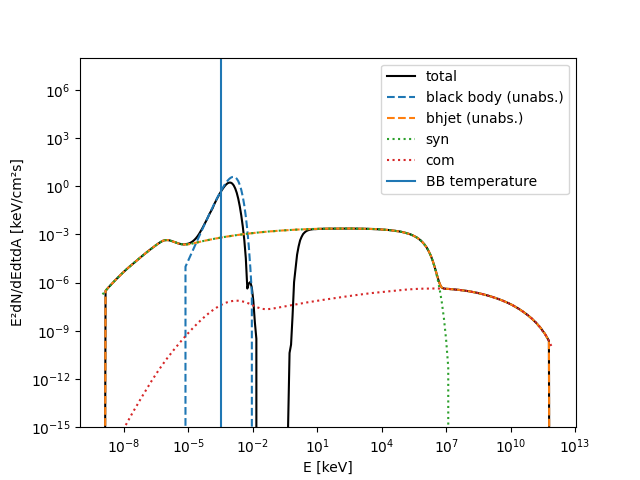

In [7]:
%matplotlib widget
EskeV = np.logspace(-9, 12, 300)
fig, ax = plt.subplots()

ax.loglog(EskeV, EskeV**2*model.fake_source(EskeV), ls="-", c="k", label="total")
ax.loglog(EskeV, EskeV**2*bbt1(EskeV), ls="--", label="black body (unabs.)")
ax.loglog(EskeV, EskeV**2*bhjet3ml(EskeV), ls="--", label="bhjet (unabs.)")

# bbt1.lg_energy_density = -1
# bhjet3ml.lg_jet_power_eddington.value = -5


ax.loglog(bhjet3ml.Egrid_keV, bhjet3ml.Egrid_keV* bhjet3ml.bhjet.get_observed_photon_integrated_flux_electron_cyclosyn(
    0, 1e30
), ls=":", label="syn")
ax.loglog(bhjet3ml.Egrid_keV, bhjet3ml.Egrid_keV* bhjet3ml.bhjet.get_observed_photon_integrated_flux_electron_compton(
    0, 1e30
), ls=":", label="com")

# for i in np.arange(-4, 2, 2):
#     bbt1.lg_energy_density = i
#     ax.loglog(EskeV, EskeV**2*bhjet3ml(EskeV), c="grey", alpha=0.5)
ax.axvline(10**bbt1.lg_temperature.value, label="BB temperature")
ax.legend()
ax.set_ylim(1e-15, 1e8)
ax.set_xlabel("E [keV]")
ax.set_ylabel("E²dN/dEdtdA [keV/cm²s]")

In [8]:

bhjet3ml.lg_jet_power_eddington.min_value = -6
bhjet3ml.lg_jet_power_eddington.max_value = -4
for par in bhjet3ml.parameters:
    bhjet3ml.parameters[par].free = False
    bhjet3ml.parameters[par].delta = 0.1
    bhjet3ml.parameters[par].prior = Uniform_prior(
        lower_bound=bhjet3ml.parameters[par].min_value,
        upper_bound=bhjet3ml.parameters[par].max_value)

bhjet3ml.lg_jet_power_eddington.free = True

bbt1.lg_temperature.min_value = -6
bbt1.lg_temperature.max_value = -3
bbt1.lg_temperature.value = -5
for par in bbt1.parameters:
    bbt1.parameters[par].free = False
    bbt1.parameters[par].delta = 0.1
    bbt1.parameters[par].prior = Uniform_prior(
        lower_bound=bbt1.parameters[par].min_value,
        upper_bound=bbt1.parameters[par].max_value)
bbt1.lg_temperature.free = True

for par in fdust.parameters:
    fdust.parameters[par].free = False
fdust.e_bmv.prior = Log_uniform_prior(lower_bound=0.1, upper_bound=10)
fdust.e_bmv.min_value = 0.1
fdust.e_bmv.max_value = 10
fdust.e_bmv.free = True

for par in fphotoabs.parameters:
    fphotoabs.parameters[par].free = False
fphotoabs.NH.prior = Log_uniform_prior(lower_bound=0.1, upper_bound=10)
fphotoabs.NH.min_value = 0.1
fphotoabs.NH.max_value = 10
fphotoabs.NH.free = True


In [9]:
fdust

* description: Extinction by dust grains from Pei (1992), suitable for IR, optical and
    * UV energy bands, including the full energy ranges of the Swift UVOT and XMM-Newton
    * OM detectors. Three models are included which characterize the extinction curves
    * of (1) the Milky Way, (2) the LMC and (3) the SMC. The models can be modified by
    * redshift and can therefore be applied to extragalactic sources. The transmission
    * is set to unity shortward of 912 Angstroms in the rest frame of the dust. This is
    * incorrect physically but does allow the model to be used in combination with an
    * X-ray photoelectric absorption model such as phabs. Parameter 1 (method) describes
    * which extinction curve (MW, LMC or SMC) will be constructed and should never be
    * allowed to float during a fit. The extinction at V, A(V) = E(B-V) x Rv. Rv should
    * typically remain frozen for a fit. Standard values for Rv are MW = 3.08, LMC = 3.16
    * and SMC = 2.93 (from table 2 of Pei 1992), although these may not be applicable
    * to more distant dusty sources.
  * formula: $n.a.$
  * parameters:
    * e_bmv_1:
      * value: 1.0
      * desc: color excess
      * min_value: 0.1
      * max_value: 10.0
      * unit: ''
      * is_normalization: false
      * delta: 0.1
      * free: true
      * prior:
        * Log_uniform_prior:
          * lower_bound:
            * value: 0.1
            * desc: Lower bound for the interval
            * min_value: 1.0e-30
            * max_value: .inf
            * unit: ''
            * is_normalization: false
            * delta: 1.0e-21
            * free: true
          * upper_bound:
            * value: 10.0
            * desc: Upper bound for the interval
            * min_value: 1.0e-30
            * max_value: .inf
            * unit: ''
            * is_normalization: false
            * delta: 10.0
            * free: true
          * K:
            * value: 1.0
            * desc: Normalization
            * min_value: null
            * max_value: null
            * unit: ''
            * is_normalization: false
            * delta: 0.1
            * free: false
    * rv_1:
      * value: 3.1
      * desc: ratio of total to selective extinction
      * min_value: null
      * max_value: null
      * unit: ''
      * is_normalization: false
      * delta: 0.1
      * free: false
    * redshift_1:
      * value: 0.0
      * desc: the redshift of the source
      * min_value: 0.0
      * max_value: 15.0
      * unit: ''
      * is_normalization: false
      * delta: 0.1
      * free: false
    * extinction_law_1:
      * value: mw
      * desc: the abundance table for the model
      * allowed values:
      * - mw
      * - lmc
      * - smc
      * defer: false
      * function: _set_extinction_law

generate some fake data

16:45:55 INFO      Using Gaussian statistic (equivalent to chi^2) with the provided errors.            ]8;id=27696;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/plugins/XYLike.py\XYLike.py]8;;\:]8;id=954933;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/plugins/XYLike.py#90\90]8;;\

         INFO      Using Gaussian statistic (equivalent to chi^2) with the provided errors.            ]8;id=102031;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/plugins/XYLike.py\XYLike.py]8;;\:]8;id=416171;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/plugins/XYLike.py#90\90]8;;\

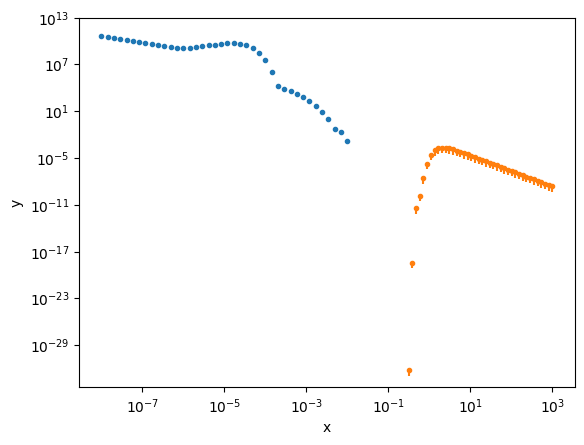

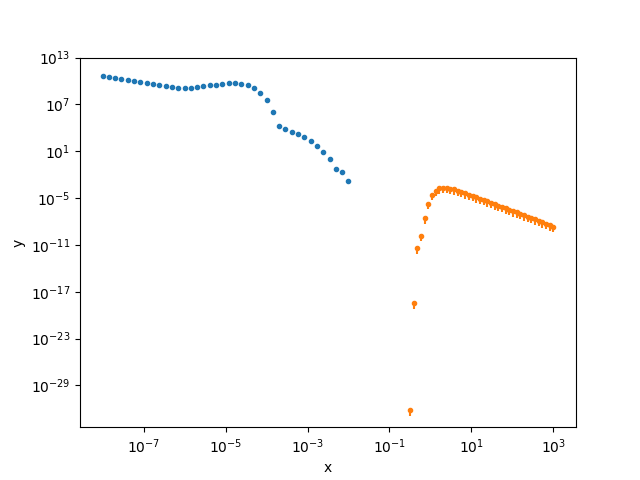

In [10]:
fake_ebins = np.logspace(-8, -2, 40)
data_points = model.fake_source(fake_ebins)
data_points[data_points<1e-50] = 0
uncertainties = 0.5 * data_points 
fake_data = XYLike("fake_data_low", x=fake_ebins, y=data_points, yerr=uncertainties)

fake_ebins2 = np.logspace(-0.5, 3, 40)
data_points2 = model.fake_source(fake_ebins2)
data_points2[data_points2<1e-50] = 0
uncertainties2 = 0.8 * data_points2 
fake_data2 = XYLike("fake_data_low2", x=fake_ebins2, y=data_points2, yerr=uncertainties2)

fig, ax = plt.subplots()
fake_data.plot(ax= ax, x_scale='log', y_scale='log')
fake_data2.plot(ax= ax, x_scale='log', y_scale='log')

In [11]:
data = DataList(fake_data, fake_data2)


In [12]:
# display all free parameters 
model.free_parameters

OrderedDict([('fake_source.spectrum.main.composite.e_bmv_1',
              Parameter e_bmv_1 = 1.0 []
              (min_value = 0.1, max_value = 10.0, delta = 0.1, free = True) [prior: Log_uniform_prior]),
             ('fake_source.spectrum.main.composite.NH_2',
              Parameter NH_2 = 3.0 [1 / cm2]
              (min_value = 0.1, max_value = 10.0, delta = 0.1, free = True) [prior: Log_uniform_prior]),
             ('fake_source.spectrum.main.composite.lg_jet_power_eddington_3',
              Parameter lg_jet_power_eddington_3 = -5.0 []
              (min_value = -6.0, max_value = -4.0, delta = 0.1, free = True) [prior: Uniform_prior]),
             ('fake_source.spectrum.main.composite.lg_temperature_4',
              Parameter lg_temperature_4 = -5.0 []
              (min_value = -6.0, max_value = -3.0, delta = 0.1, free = True) [prior: Uniform_prior])])

In [13]:

nlive = 100
bayes = BayesianAnalysis(model, data)
bayes.set_sampler("ultranest")

bayes.sampler.setup(
    log_dir="./ultranest_testabs",
    min_num_live_points=nlive,
    dlogz=0.5, Lepsilon=0.8,
    resume="resume")
bayes.sample()



16:46:08 INFO      sampler set to ultranest                                                ]8;id=78894;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/bayesian/bayesian_analysis.py\bayesian_analysis.py]8;;\:]8;id=125365;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/bayesian/bayesian_analysis.py#186\186]8;;\

[ultranest] Resuming from 1907 stored points


[ultranest] Explored until L=-0.1   [-0.9688..-0.6539]*| it/evals=1800/10138 eff=inf% N=100        0 0   0 0 =100 0 
[ultranest] Likelihood function evaluations: 10138
[ultranest] Writing samples and results to disk ...
[ultranest] Writing samples and results to disk ... done
[ultranest]   logZ = -16.9 +- 0.3282
[ultranest] Effective samples strategy satisfied (ESS = 596.7, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.22 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy wants 98 minimum live points (dlogz from 0.25 to 0.88, need <0.5)
[ultranest]   logZ error budget: single: 0.37 bs:0.33 tail:0.16 total:0.36 required:<0.50
[ultranest] done iterating.


16:46:12 INFO      fit restored to maximum of posterior                                         ]8;id=460125;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/bayesian/sampler_base.py\sampler_base.py]8;;\:]8;id=284376;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/bayesian/sampler_base.py#168\168]8;;\

         INFO      fit restored to maximum of posterior                                         ]8;id=94371;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/bayesian/sampler_base.py\sampler_base.py]8;;\:]8;id=827698;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/bayesian/sampler_base.py#168\168]8;;\

...

,result,unit
parameter,,
fake_source.spectrum.main.composite.e_bmv_1,1.018 -0.05 +0.034,
fake_source.spectrum.main.composite.NH_2,3.005 -0.011 +0.15,1 / cm2
fake_source...lg_jet_power_eddington_3,-4.998 -0.04 +0.026,
fake_source...lg_temperature_4,-4.998 -0.018 +0.010,


Values of -log(posterior) at the minimum:

,-log(posterior)
fake_data_low,-1.238214
fake_data_low2,-1.132387
total,-2.370601


Values of statistical measures:

,statistical measures
AIC,13.274535
BIC,22.269308
DIC,8.587127
PDIC,0.904640
log(Z),-7.332314


In [14]:
bayes.results.write_to(
    f"./ultranest_test/threeml_results_testabs_n{nlive}.h5",
    overwrite=True)

We can load it back in like this

In [15]:
ar = load_analysis_results(f"./ultranest_test/threeml_results_testabs_n{nlive}.h5")

and make e.g. a corner plot to that things make sense

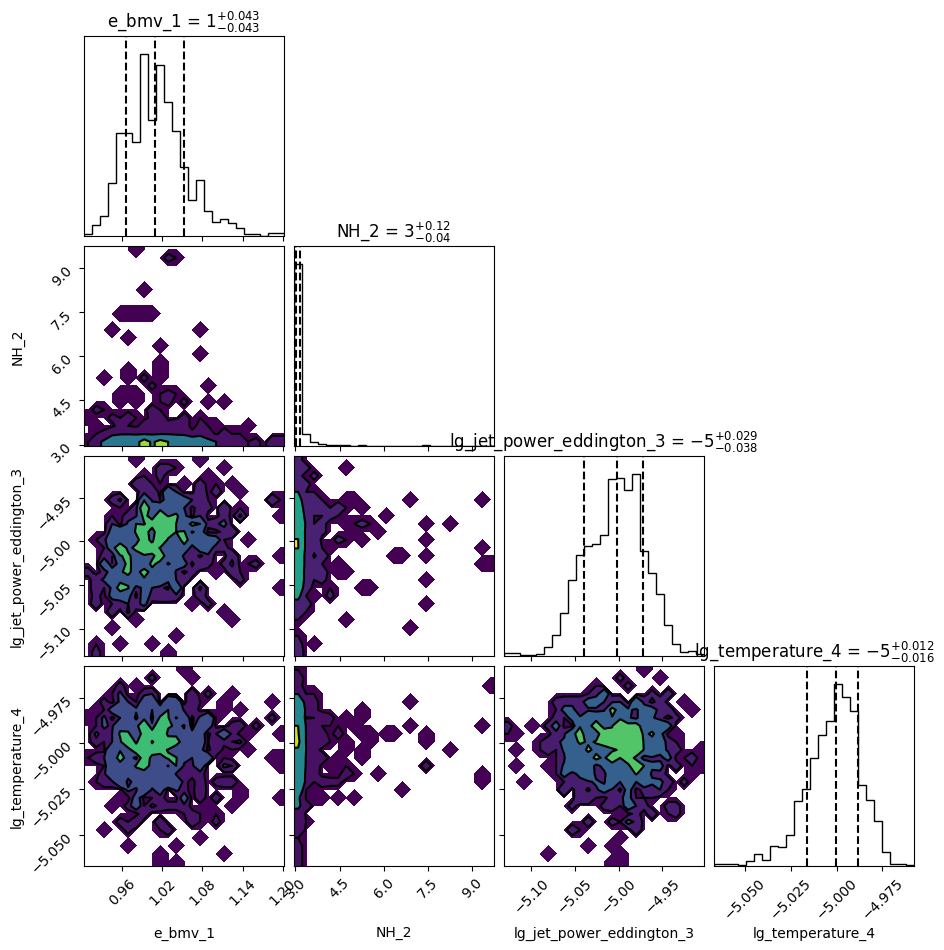

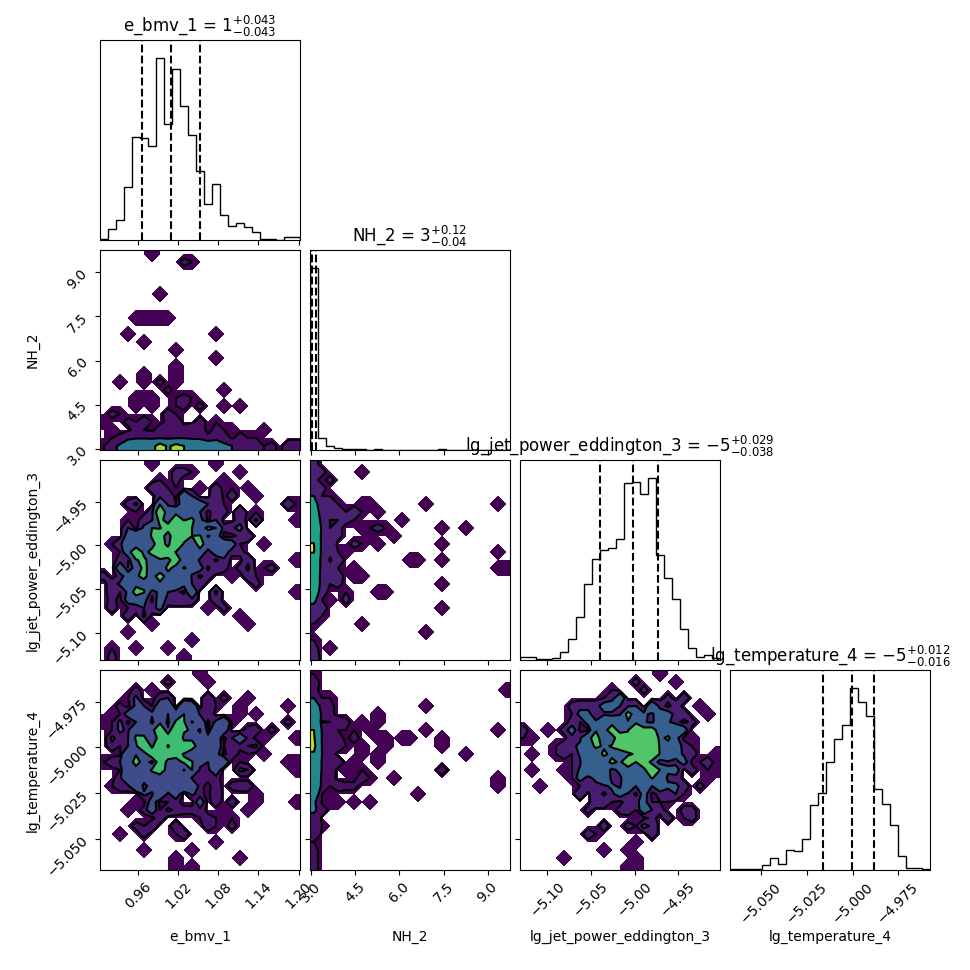

In [16]:
ar.corner_plot()